<a href="https://colab.research.google.com/github/partha2412/Time-Series-Forecast/blob/main/TimeSeries_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [526]:
import pandas as pd

In [527]:
tdf = pd.read_parquet("/content/drive/MyDrive/DBA/Project/demand_forecasting_training.parquet")
tdf.head()

,Store_ID,SKU_ID,Month,Sales,Category,BaselineForecast
0,S01,SKU_0483,2022-06-01,4,C,0.6
1,S01,SKU_0591,2022-06-01,198,C,0.0
2,S01,SKU_0855,2022-06-01,1366,B,2331.98
3,S01,SKU_1176,2022-06-01,71160,A,42525.27
4,S01,SKU_1378,2022-06-01,2,C,1.63


In [528]:
len(tdf[ (tdf["Sales"]=="NoSales") & (tdf["Category"]=="C") ])

153

In [529]:
len(tdf[ (tdf["Sales"]=="0") ])

522

In [530]:
len(tdf[ (tdf["BaselineForecast"]=="NoForecasts") ])

199

In [531]:
len(tdf[ (tdf["BaselineForecast"]=="0.0") ])

396

In [532]:
tdf.shape

(2945, 6)

In [533]:
tdf.isnull().sum()

,0
Store_ID,0
SKU_ID,0
Month,0
Sales,0
Category,0
BaselineForecast,0


In [534]:
tdf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2945 entries, 0 to 2944
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Store_ID          2945 non-null   object
 1   SKU_ID            2945 non-null   object
 2   Month             2945 non-null   object
 3   Sales             2945 non-null   object
 4   Category          2945 non-null   object
 5   BaselineForecast  2945 non-null   object
dtypes: object(6)
memory usage: 225.6+ KB


In [535]:
tdf.dtypes

,0
Store_ID,object
SKU_ID,object
Month,object
Sales,object
Category,object
BaselineForecast,object


In [536]:
vdf = pd.read_parquet("/content/drive/MyDrive/DBA/Project/demand_forecasting_validation.parquet")
vdf.head()

,Store_ID,SKU_ID,Month,Sales,Category,BaselineForecast
2945,S01,SKU_0483,2025-01-01,0,C,0.63
2946,S01,SKU_0591,2025-01-01,24,C,9.69
2947,S01,SKU_0855,2025-01-01,1324,B,774.5699999999999
2948,S01,SKU_1176,2025-01-01,117246,A,46035.71
2949,S01,SKU_1378,2025-01-01,4,C,2.0700000000000003


In [537]:
vdf.shape

(475, 6)

In [538]:
vdf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 475 entries, 2945 to 3419
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Store_ID          475 non-null    object
 1   SKU_ID            475 non-null    object
 2   Month             475 non-null    object
 3   Sales             475 non-null    object
 4   Category          475 non-null    object
 5   BaselineForecast  475 non-null    object
dtypes: object(6)
memory usage: 42.1+ KB


In [539]:
vdf.dtypes

,0
Store_ID,object
SKU_ID,object
Month,object
Sales,object
Category,object
BaselineForecast,object


# **Phase 1: Data Acquisition & Initial Exploration**

---
*   Access and load compressed Parquet files (training and validation sets from Azure Blob storage).
*   Clean and preprocess the data.
*   Analyze data characteristics: quantity of SKUs and Stores, SKU types, and general demand patterns etc.

#preprocessing

In [540]:
tdf.head()

,Store_ID,SKU_ID,Month,Sales,Category,BaselineForecast
0,S01,SKU_0483,2022-06-01,4,C,0.6
1,S01,SKU_0591,2022-06-01,198,C,0.0
2,S01,SKU_0855,2022-06-01,1366,B,2331.98
3,S01,SKU_1176,2022-06-01,71160,A,42525.27
4,S01,SKU_1378,2022-06-01,2,C,1.63


In [541]:
# tdf[ (tdf["Store_ID"]=="S01") & (tdf["SKU_ID"]=="SKU_0483") ]

In [542]:
# 63*25

fix the the data

In [543]:
import pandas as pd

def fix_month(s):
    if isinstance(s, pd.Timestamp):
        return s.replace(day=1)

    parts = str(s).split(' ')[0].split('-')
    y, a, b = int(parts[0]), int(parts[1]), int(parts[2])

    # Case 1: Day is in middle position (YYYY-DD-MM), e.g., 2024-15-01 -> month = 1
    if a > 12:
        month = b
    # Case 2: Day is in last position (YYYY-MM-DD), e.g., 2024-01-15 -> month = 1
    elif b > 12:
        month = a
    # Case 3: Swapped day 1 (YYYY-DD-MM for 1st of month b), e.g., 2023-01-12 -> month = 12
    elif a == 1 and 1 < b <= 12:
        month = b
    else:
        month = a

    return pd.Timestamp(year=y, month=month, day=1)

def clean_and_preprocess(df):
    df = df.copy()

    # Clean Numeric Columns
    df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce').fillna(0).astype('float64')
    df['BaselineForecast'] = pd.to_numeric(df['BaselineForecast'], errors='coerce').fillna(0).astype('float64')

    # Categorical / String Cleaning
    df['Category'] = df['Category'].astype('category')
    df['Store_ID'] = df['Store_ID'].astype(str)
    df['SKU_ID'] = df['SKU_ID'].astype(str)

    # Parse Dates safely
    df['Month'] = df['Month'].apply(fix_month)
    return df

In [544]:
# Apply to both Train and Validation sets
tdf = clean_and_preprocess(tdf)
vdf = clean_and_preprocess(vdf)

In [545]:
tdf

,Store_ID,SKU_ID,Month,Sales,Category,BaselineForecast
0,S01,SKU_0483,2022-06-01,4.0,C,0.60
1,S01,SKU_0591,2022-06-01,198.0,C,0.00
2,S01,SKU_0855,2022-06-01,1366.0,B,2331.98
3,S01,SKU_1176,2022-06-01,71160.0,A,42525.27
4,S01,SKU_1378,2022-06-01,2.0,C,1.63
...,...,...,...,...,...,...
2940,S24,SKU_0623,2024-12-01,780.0,B,0.00
2941,S24,SKU_1176,2024-12-01,87904.0,A,38425.06
2942,S25,SKU_0127,2024-12-01,0.0,C,0.48
2943,S25,SKU_0609,2024-12-01,907.0,B,501.74


In [546]:
vdf

,Store_ID,SKU_ID,Month,Sales,Category,BaselineForecast
2945,S01,SKU_0483,2025-01-01,0.0,C,0.63
2946,S01,SKU_0591,2025-01-01,24.0,C,9.69
2947,S01,SKU_0855,2025-01-01,1324.0,B,774.57
2948,S01,SKU_1176,2025-01-01,117246.0,A,46035.71
2949,S01,SKU_1378,2025-01-01,4.0,C,2.07
...,...,...,...,...,...,...
3415,S24,SKU_0623,2025-05-01,2792.0,B,868.80
3416,S24,SKU_1176,2025-05-01,74610.0,A,34958.52
3417,S25,SKU_0127,2025-05-01,0.0,C,0.63
3418,S25,SKU_0609,2025-05-01,784.0,B,390.66


In [547]:
# tdf['Sales'] = pd.to_numeric(tdf['Sales'], errors='coerce').fillna(0).astype('float64')
# tdf['BaselineForecast'] = pd.to_numeric(tdf['BaselineForecast'], errors='coerce').fillna(0).astype('float64')
# tdf['Category'] = tdf["Category"].astype('category')
# tdf['Store_ID'] = tdf["Store_ID"].astype('str')
# tdf['SKU_ID'] = tdf["SKU_ID"].astype('str')

# tdf['Month'] = tdf['Month'].apply(fix_month)

In [548]:
# (tdf['Month'].dt.day.value_counts())

In [549]:
# tdf.dtypes

In [550]:
# vdf.head()

In [551]:
# vdf['Sales'] = pd.to_numeric(vdf['Sales'], errors='coerce').fillna(0).astype('float64')
# vdf['BaselineForecast'] = pd.to_numeric(vdf['BaselineForecast'], errors='coerce').fillna(0).astype('float64')
# vdf['Category'] = vdf["Category"].astype('category')
# vdf['Store_ID'] = vdf["Store_ID"].astype('str')
# vdf['SKU_ID'] = vdf["SKU_ID"].astype('str')
# # vdf['Month'] = pd.to_datetime(vdf['Month']).dt.to_period('M').dt.to_timestamp()
# vdf['Month'] = vdf['Month'].apply(fix_month)

In [552]:
# vdf.dtypes

null value check

In [553]:
tdf.isnull().sum()

,0
Store_ID,0
SKU_ID,0
Month,0
Sales,0
Category,0
BaselineForecast,0


In [554]:
vdf.isnull().sum()

,0
Store_ID,0
SKU_ID,0
Month,0
Sales,0
Category,0
BaselineForecast,0


duplicated check

In [555]:
tdf[tdf.duplicated()]

,Store_ID,SKU_ID,Month,Sales,Category,BaselineForecast


In [556]:
vdf[vdf.duplicated()]

,Store_ID,SKU_ID,Month,Sales,Category,BaselineForecast


In [557]:
print("Training set")
print("Rows:", len(tdf))
print("Stores:", tdf['Store_ID'].nunique())
print("SKUs:", tdf['SKU_ID'].nunique())
print("Categories:", tdf['Category'].nunique())
print("Months:", tdf['Month'].nunique())
print(tdf['Month'].min(), "to", tdf['Month'].max())
print(tdf['Category'].value_counts())

Training set
Rows: 2945
Stores: 25
SKUs: 63
Categories: 3
Months: 31
2022-06-01 00:00:00 to 2024-12-01 00:00:00
Category
C    1395
A     775
B     775
Name: count, dtype: int64


In [558]:
# tdf['Month'].min(), tdf['Month'].max()
# tdf['Month'].sort_values().unique()

In [559]:
vdf['Month'].value_counts().sort_index()

,count
Month,
2025-01-01,95
2025-02-01,95
2025-03-01,95
2025-04-01,95
2025-05-01,95


In [560]:
print("validation set")

print("Rows:", len(vdf))
print("Stores:", vdf['Store_ID'].nunique())
print("SKUs:", vdf['SKU_ID'].nunique())
print("Categories:", vdf['Category'].nunique())
print("Months:", vdf['Month'].nunique())
print(vdf['Month'].min(), "to", vdf['Month'].max())
print(vdf['Category'].value_counts())

validation set
Rows: 475
Stores: 25
SKUs: 63
Categories: 3
Months: 5
2025-01-01 00:00:00 to 2025-05-01 00:00:00
Category
C    225
A    125
B    125
Name: count, dtype: int64


In [561]:
# vdf['Month'].value_counts().sort_index()

In [562]:
# tdf.tail(5)

save the clean train validation dataframe

In [563]:
# tdf.to_excel('train_data.xlsx', index=False)
# vdf.to_excel('validation_data.xlsx', index=False)

no of series for each category

In [564]:
tdf.groupby('Category').apply(
    lambda x: x[['Store_ID', 'SKU_ID']].drop_duplicates().shape[0]
)

/tmp/ipykernel_1782/2673639780.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tdf.groupby('Category').apply(
/tmp/ipykernel_1782/2673639780.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tdf.groupby('Category').apply(


,0
Category,
A,25
B,25
C,45


##variation in the number of months per Store-SKU series

In [565]:
series_counts = (
    tdf.groupby(['Store_ID', 'SKU_ID'])
       .size()
       .reset_index(name='months')
)

series_counts.head(4)

,Store_ID,SKU_ID,months
0,S01,SKU_0483,31
1,S01,SKU_0591,31
2,S01,SKU_0855,31
3,S01,SKU_1176,31


In [566]:
series_counts['months'].value_counts()

,count
months,
31,95


In [567]:
# series_counts['months'].describe()

##Does every Store-SKU series contain every month from June 2022 through December 2024 exactly once?

In [568]:
expected_months = pd.date_range(
    start='2022-06-01',
    end='2024-12-01',
    freq='MS'
)

print("Expected months:", len(expected_months))

Expected months: 31


In [569]:
for (store, sku), group in tdf.groupby(['Store_ID', 'SKU_ID']):
    months = pd.to_datetime(group['Month']).sort_values().unique()

    if len(months) != len(expected_months) or not all(months == expected_months):
        print("Problem:", store, sku)

every Store-SKU series has the complete 31-month sequence.

##Check trend and seasonality

In [570]:
# Convert Month to datetime
tdf['Month'] = pd.to_datetime(tdf['Month'])

# Pick one Store-SKU series from each category
for category in ['A', 'B', 'C']:
    sample = tdf[tdf['Category'] == category].iloc[0]

    store = sample['Store_ID']
    sku = sample['SKU_ID']

    series = (
        tdf[
            (tdf['Store_ID'] == store) &
            (tdf['SKU_ID'] == sku)
        ]
        .sort_values('Month')
    )

    print(f"Category {category}: {store} - {sku}")

Category A: S01 - SKU_1176
Category B: S01 - SKU_0855
Category C: S01 - SKU_0483


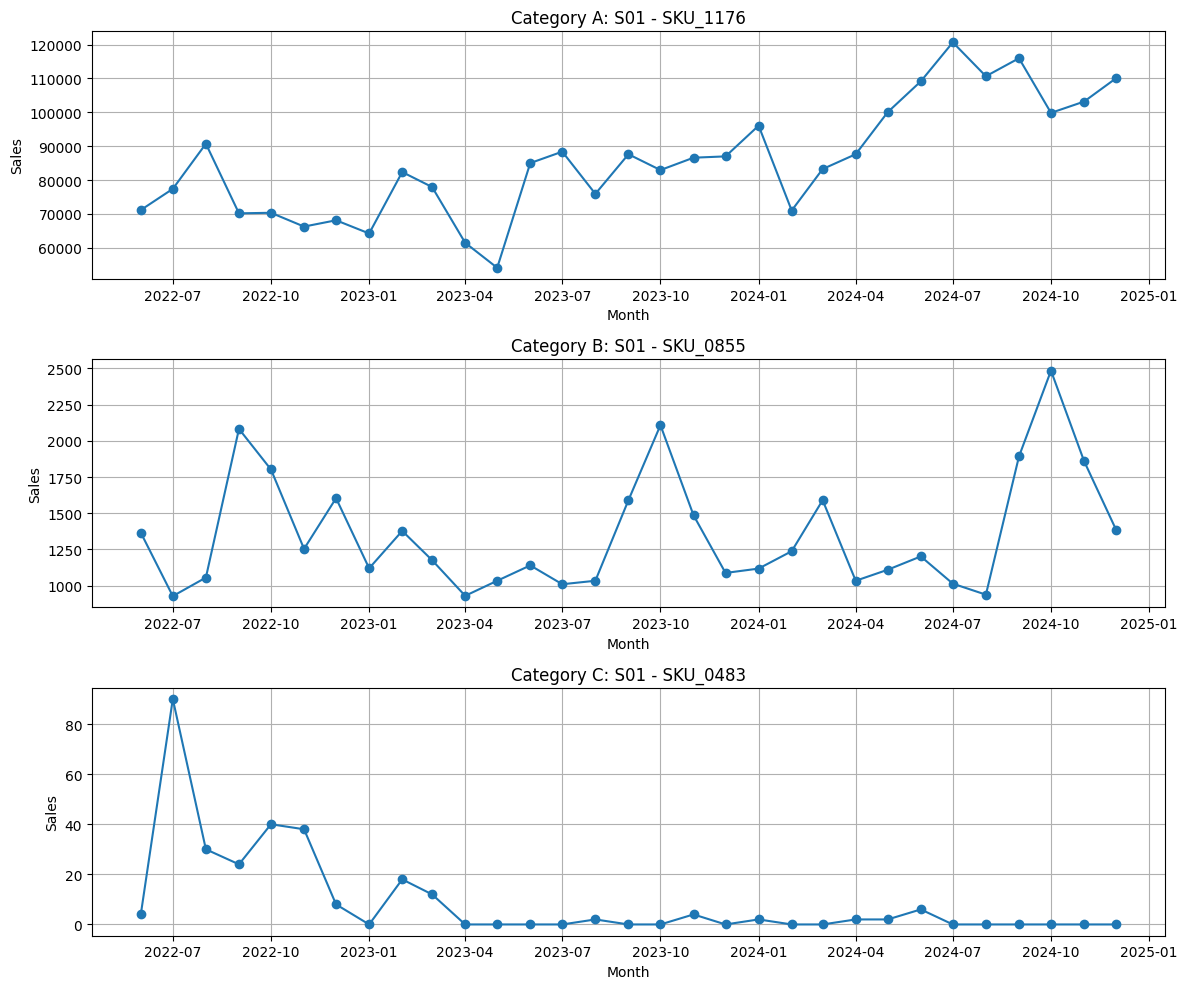

In [571]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

for ax, category in zip(axes, ['A', 'B', 'C']):

    sample = tdf[tdf['Category'] == category].iloc[0]

    store = sample['Store_ID']
    sku = sample['SKU_ID']

    series = (
        tdf[
            (tdf['Store_ID'] == store) &
            (tdf['SKU_ID'] == sku)
        ]
        .sort_values('Month')
    )

    ax.plot(series['Month'], series['Sales'], marker='o')
    ax.set_title(f"Category {category}: {store} - {sku}")
    ax.set_xlabel("Month")
    ax.set_ylabel("Sales")
    ax.grid(True)

plt.tight_layout()
plt.show()

##Stationarity test using ADF test

In [572]:
from statsmodels.tsa.stattools import adfuller

for category in ['A', 'B', 'C']:

    sample = tdf[tdf['Category'] == category].iloc[0]

    store = sample['Store_ID']
    sku = sample['SKU_ID']

    series = (
        tdf[
            (tdf['Store_ID'] == store) &
            (tdf['SKU_ID'] == sku)
        ]
        .sort_values('Month')['Sales']
        .astype(float)
    )

    result = adfuller(series)

    print(f"\nCategory {category}: {store} - {sku}")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])


Category A: S01 - SKU_1176
ADF Statistic: -1.8580182050399283
p-value: 0.35206090362733417

Category B: S01 - SKU_0855
ADF Statistic: -4.326244885890982
p-value: 0.0003999542843105062

Category C: S01 - SKU_0483
ADF Statistic: -3.4727061753127795
p-value: 0.008716357432071508


##ACF and PACF

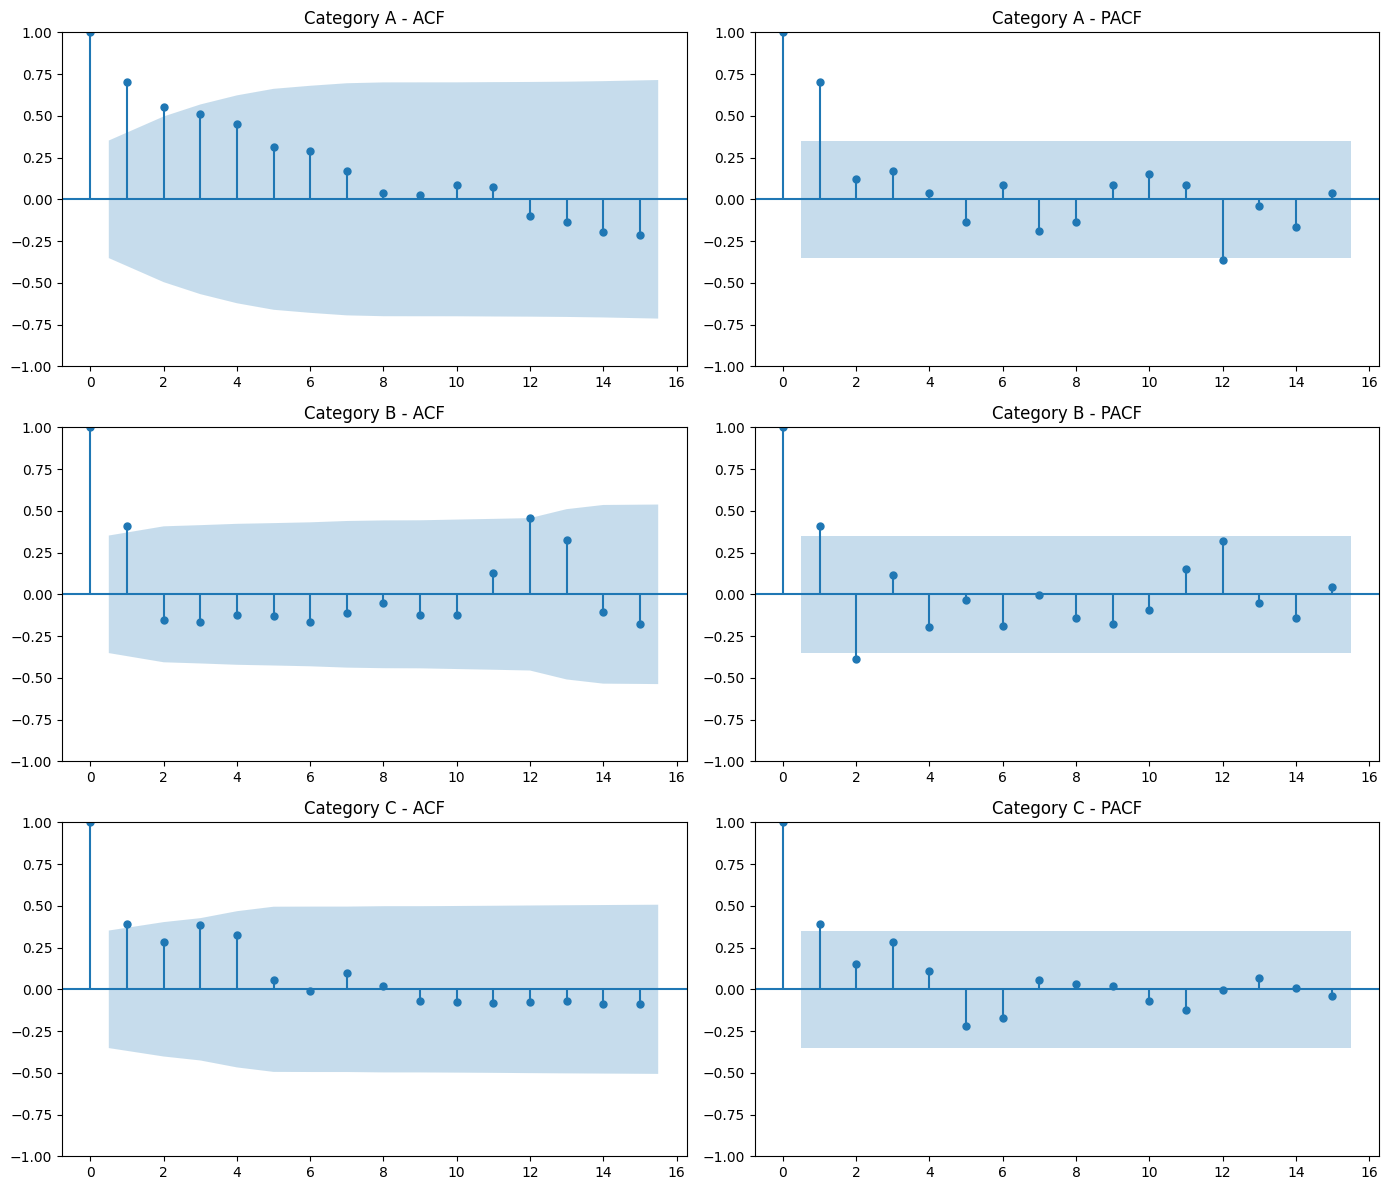

In [573]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for row, category in enumerate(['A', 'B', 'C']):

    sample = tdf[tdf['Category'] == category].iloc[0]

    store = sample['Store_ID']
    sku = sample['SKU_ID']

    series = (
        tdf[
            (tdf['Store_ID'] == store) &
            (tdf['SKU_ID'] == sku)
        ]
        .sort_values('Month')['Sales']
        .astype(float)
    )

    # ACF
    plot_acf(
        series,
        lags=15,
        ax=axes[row, 0]
    )

    # PACF
    plot_pacf(
        series,
        lags=15,
        ax=axes[row, 1],
        method='ywm'
    )

    axes[row, 0].set_title(f'Category {category} - ACF')
    axes[row, 1].set_title(f'Category {category} - PACF')

plt.tight_layout()
plt.show()

make category A sesonal

In [574]:
# First difference Category A
sample = tdf[tdf['Category'] == 'A'].iloc[0]

store = sample['Store_ID']
sku = sample['SKU_ID']

series_A = (
    tdf[
        (tdf['Store_ID'] == store) &
        (tdf['SKU_ID'] == sku)
    ]
    .sort_values('Month')['Sales']
    .astype(float)
)

diff_A = series_A.diff().dropna()

print("Original length:", len(series_A))
print("Differenced length:", len(diff_A))

Original length: 31
Differenced length: 30


In [575]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(diff_A)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -4.128652127900363
p-value: 0.0008681320906527184


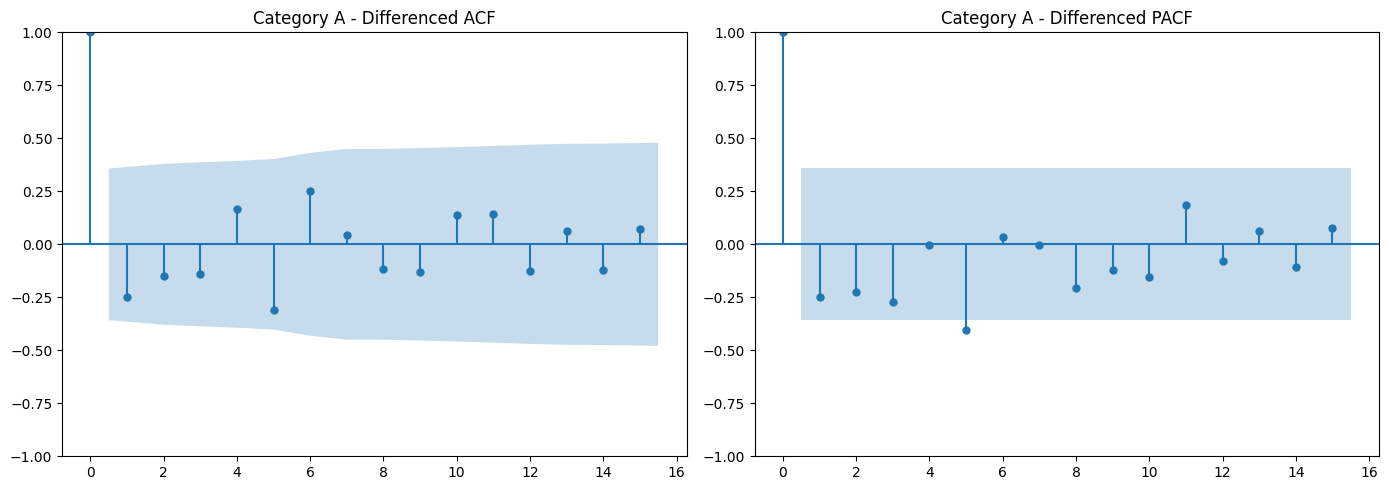

In [576]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(diff_A, lags=15, ax=axes[0])
plot_pacf(diff_A, lags=15, ax=axes[1], method='ywm')

axes[0].set_title("Category A - Differenced ACF")
axes[1].set_title("Category A - Differenced PACF")

plt.tight_layout()
plt.show()

##Build forecasts models

In [577]:
# Create combined Store + SKU column in training data (tdf)
tdf["Store_SKU"] = tdf["Store_ID"].astype(str) + "_" + tdf["SKU_ID"].astype(str)

# Create combined Store + SKU column in validation data (vdf)
vdf["Store_SKU"] = vdf["Store_ID"].astype(str) + "_" + vdf["SKU_ID"].astype(str)

In [578]:
tdf.head()

,Store_ID,SKU_ID,Month,Sales,Category,BaselineForecast,Store_SKU
0,S01,SKU_0483,2022-06-01,4.0,C,0.60,S01_SKU_0483
1,S01,SKU_0591,2022-06-01,198.0,C,0.00,S01_SKU_0591
2,S01,SKU_0855,2022-06-01,1366.0,B,2331.98,S01_SKU_0855
3,S01,SKU_1176,2022-06-01,71160.0,A,42525.27,S01_SKU_1176
4,S01,SKU_1378,2022-06-01,2.0,C,1.63,S01_SKU_1378


In [579]:
import numpy as np
import pandas as pd


def evaluate_models(df, actual_col, model_cols, group_by_col=None):
    """Evaluates multiple forecasting models against actual values using MAE, RMSE, WAPE, and BIAS.

    Parameters:
    - df: DataFrame containing actual values and model predictions.
    - actual_col: str, name of the target column (e.g., 'Sales').
    - model_cols: list of str, names of prediction columns (e.g.,
    ['BaselineForecast', 'LGBM_Pred']).
    - group_by_col: str (optional), column to break down evaluation by (e.g.,
    'Category').

    Returns:
    - Summary DataFrame comparing performance metrics for all models.
    """
    metrics_list = []

    for model_name in model_cols:
        y_true = df[actual_col].values
        y_pred = df[model_name].values

        # 1. Overall Metrics
        mae = np.mean(np.abs(y_true - y_pred))
        rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
        wape = (
            (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100
            if np.sum(y_true) != 0
            else np.nan
        )
        bias = np.mean(y_pred - y_true)

        metrics_list.append({
            "Model": model_name,
            "Scope": "Overall",
            "MAE": round(mae, 2),
            "RMSE": round(rmse, 2),
            "WAPE (%)": round(wape, 2),
            "BIAS": round(bias, 2),
        })

        # 2. Category / Group Metrics (Optional)
        if group_by_col:
            for group_val, group_df in df.groupby(group_by_col):
                g_true = group_df[actual_col].values
                g_pred = group_df[model_name].values

                g_mae = np.mean(np.abs(g_true - g_pred))
                g_rmse = np.sqrt(np.mean((g_true - g_pred) ** 2))
                g_wape = (
                    (np.sum(np.abs(g_true - g_pred)) / np.sum(g_true)) * 100
                    if np.sum(g_true) != 0
                    else np.nan
                )
                g_bias = np.mean(g_pred - g_true)

                metrics_list.append({
                    "Model": model_name,
                    "Scope": f"{group_by_col}: {group_val}",
                    "MAE": round(g_mae, 2),
                    "RMSE": round(g_rmse, 2),
                    "WAPE (%)": round(g_wape, 2),
                    "BIAS": round(g_bias, 2),
                })

    return pd.DataFrame(metrics_list)


# Example usage:
# evaluation_results = evaluate_models(
#     df=vdf,
#     actual_col='Sales',
#     model_cols=['BaselineForecast', 'LGBM_Forecast', 'XGB_Forecast'],
#     group_by_col='Category'
# )
# print(evaluation_results)

create Naive Model

In [581]:
# Create a clean working copy of vdf so raw vdf remains completely untouched
vdf_eval = vdf.copy()

# Ensure composite keys exist in temporary datasets
tdf_temp = tdf.copy()
tdf_temp["Store_SKU"] = (
    tdf_temp["Store_ID"].astype(str) + "_" + tdf_temp["SKU_ID"].astype(str)
)
vdf_eval["Store_SKU"] = (
    vdf_eval["Store_ID"].astype(str) + "_" + vdf_eval["SKU_ID"].astype(str)
)

tdf_temp["Month"] = pd.to_datetime(tdf_temp["Month"])
vdf_eval["Month"] = pd.to_datetime(vdf_eval["Month"])


# -------------------------------------------------------------
# 1. Simple Naive Model (Last Known Value from Dec 2024)
# -------------------------------------------------------------
last_training_month = tdf_temp["Month"].max()

naive_last_df = tdf_temp[tdf_temp["Month"] == last_training_month][
    ["Store_SKU", "Sales"]
].rename(columns={"Sales": "Naive_LastValue"})

vdf_eval = vdf_eval.merge(naive_last_df, on="Store_SKU", how="left")
vdf_eval["Naive_LastValue"] = vdf_eval["Naive_LastValue"].fillna(0)

Create Seasonal Naive

In [582]:
vdf_eval["Prev_Year_Month"] = vdf_eval["Month"] - pd.DateOffset(years=1)

seasonal_df = tdf_temp[["Store_SKU", "Month", "Sales"]].rename(
    columns={"Month": "Prev_Year_Month", "Sales": "Seasonal_Naive"}
)

vdf_eval = vdf_eval.merge(
    seasonal_df, on=["Store_SKU", "Prev_Year_Month"], how="left"
).drop(columns=["Prev_Year_Month"])

vdf_eval["Seasonal_Naive"] = vdf_eval["Seasonal_Naive"].fillna(0)

In [583]:
vdf_eval.head()

,Store_ID,SKU_ID,Month,Sales,Category,BaselineForecast,Store_SKU,Naive_LastValue,Seasonal_Naive
0,S01,SKU_0483,2025-01-01,0.0,C,0.63,S01_SKU_0483,0.0,2.0
1,S01,SKU_0591,2025-01-01,24.0,C,9.69,S01_SKU_0591,6.0,0.0
2,S01,SKU_0855,2025-01-01,1324.0,B,774.57,S01_SKU_0855,1386.0,1118.0
3,S01,SKU_1176,2025-01-01,117246.0,A,46035.71,S01_SKU_1176,110060.0,96064.0
4,S01,SKU_1378,2025-01-01,4.0,C,2.07,S01_SKU_1378,0.0,4.0


elovute

In [642]:
evaluation_results = evaluate_models(
    df=vdf_eval,
    actual_col="Sales",
    model_cols=["BaselineForecast", "Naive_LastValue", "Seasonal_Naive"],
    # group_by_col="Category"
)

evaluation_results

,Model,Scope,MAE,RMSE,WAPE (%),BIAS
0,BaselineForecast,Overall,8271.71,18413.37,53.51,-8250.73
1,Naive_LastValue,Overall,2690.29,6535.78,17.40,775.48
2,Seasonal_Naive,Overall,2856.44,6965.10,18.48,-2242.20


#Build LightBoost model

In [584]:
# # Combine train + validation
# full = pd.concat([tdf, vdf], ignore_index=True)

# # Convert Month first
# full['Month'] = pd.to_datetime(full['Month'])

# # Make Sales numeric
# full['Sales'] = pd.to_numeric(full['Sales'], errors='coerce')

# # Sort chronologically for each Store-SKU
# full = full.sort_values(
#     ['Store_ID', 'SKU_ID', 'Month']
# ).reset_index(drop=True)

# # Group each Store-SKU time series
# g = full.groupby(['Store_ID', 'SKU_ID'])['Sales']

# # Create lag features
# for lag in [2, 3, 4, 5, 6, 7]:
#     full[f'lag{lag}'] = g.shift(lag)

# # Rolling features
# full['roll_mean_3'] = full[
#     ['lag2', 'lag3', 'lag4']
# ].mean(axis=1)

# full['roll_mean_6'] = full[
#     ['lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7']
# ].mean(axis=1)

# # Percentage of zero demand in previous 6 periods
# full['zero_rate_6'] = (
#     full[
#         ['lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7']
#     ] == 0
# ).mean(axis=1)

# # Month number
# full['month_num'] = full['Month'].dt.month

# # Encode categorical columns
# full['Category_code'] = full['Category'].astype('category').cat.codes
# full['Store_code'] = full['Store_ID'].astype('category').cat.codes
# full['SKU_code'] = full['SKU_ID'].astype('category').cat.codes

In [585]:
# print(full.columns.tolist())

Train ONE LightGBM model on everything

In [586]:
# import lightgbm as lgb

# FEATURES = [
#     'lag2',
#     'lag3',
#     'lag4',
#     'lag5',
#     'lag6',
#     'lag7',
#     'roll_mean_3',
#     'roll_mean_6',
#     'zero_rate_6',
#     'month_num',
#     'Category_code',
#     'Store_code',
#     'SKU_code'
# ]

# print("Number of features:", len(FEATURES))
# print(FEATURES)

# train_mask = full['Month'] < '2025-01-01'
# val_mask = full['Month'] >= '2025-01-01'

# train_data = full.loc[train_mask].dropna(subset=FEATURES)
# val_data = full.loc[val_mask].dropna(subset=FEATURES)

# X_train = train_data[FEATURES]
# y_train = train_data['Sales']

# X_val = val_data[FEATURES]
# y_val = val_data['Sales']

# print("X_train shape:", X_train.shape)
# print("X_val shape:", X_val.shape)

train

In [587]:
# model = lgb.train(
#     {
#         'objective': 'regression',
#         'metric': 'rmse',
#         'learning_rate': 0.05
#     },
#     lgb.Dataset(
#         X_train,
#         label=np.log1p(y_train)
#     ),
#     num_boost_round=400
# )

predict

In [588]:
# val_pred = model.predict(X_val)

# val_pred = np.expm1(val_pred)
# val_pred = np.clip(val_pred, 0, None)

In [589]:
# def wape(y_true, y_pred):
#     return (
#         100 *
#         np.sum(np.abs(y_true - y_pred))
#         / np.sum(np.abs(y_true))
#     )

# print(
#     "LightGBM WAPE:",
#     wape(y_val.values, val_pred),
#     "%"
# )

#ARIMA modelling

In [590]:
# sample = tdf[tdf['Category'] == 'A'].iloc[0]

# store = sample['Store_ID']
# sku = sample['SKU_ID']

# series_A = (
#     tdf[
#         (tdf['Store_ID'] == store) &
#         (tdf['SKU_ID'] == sku)
#     ]
#     .sort_values('Month')['Sales']
#     .astype(float)
# )

# print(store, sku)

In [591]:
# from statsmodels.tsa.arima.model import ARIMA

# model = ARIMA(series_A, order=(1, 1, 0))
# model_fit = model.fit()

In [592]:
# print(model_fit.summary())

try all possible p,q value, while d=1

In [593]:
# from statsmodels.tsa.arima.model import ARIMA

# orders = [
#     (0, 1, 0),
#     (1, 1, 0),
#     (0, 1, 1),
#     (1, 1, 1),
#     (2, 1, 0),
#     (0, 1, 2),
#     (2, 1, 1)
# ]

# results = []

# for order in orders:
#     model = ARIMA(series_A, order=order)
#     fitted = model.fit()

#     results.append({
#         'Order': order,
#         'AIC': fitted.aic,
#         'BIC': fitted.bic
#     })

# results_df = pd.DataFrame(results).sort_values('AIC')


In [594]:
# print(results_df)

calculate MAE/RMSE/WAPE.

In [595]:
# from statsmodels.tsa.arima.model import ARIMA
# from sklearn.metrics import mean_absolute_error, mean_squared_error
# import numpy as np

# # Fit ARIMA(0,1,0) on Category A training series
# model = ARIMA(series_A, order=(0, 1, 0))
# model_fit = model.fit()

# # Forecast 5 validation months: Jan-May 2025
# forecast_A = model_fit.forecast(steps=5)

# print("ARIMA(0,1,0) Forecast:")
# print(forecast_A)

In [596]:
# actual_A = (
#     validation[
#         (validation['Store_ID'] == store) &
#         (validation['SKU_ID'] == sku)
#     ]
#     .sort_values('Month')['Sales']
#     .astype(float)
# )

# print("Actual:")
# print(actual_A.values)

In [597]:
# actual = np.array(actual_A, dtype=float)
# forecast = np.array(forecast_A, dtype=float)

# error = np.abs(actual - forecast)

# print("Actual:", actual)
# print("Forecast:", forecast)

# print("Total absolute error:", error.sum())
# print("Total actual sales:", np.abs(actual).sum())

# wape = error.sum() / np.abs(actual).sum()

# print("WAPE:", wape)
# print("WAPE %:", wape * 100)

In [598]:
# naive_A = (
#     validation[
#         (validation['Store_ID'] == store) &
#         (validation['SKU_ID'] == sku)
#     ]
#     .sort_values('Month')['NaiveForecast']
#     .astype(float)
# )

# mae = mean_absolute_error(actual_A, naive_A)
# rmse = np.sqrt(mean_squared_error(actual_A, naive_A))
# wape = np.sum(np.abs(actual_A - naive_A)) / np.sum(np.abs(actual_A))

# print("Naive - Category A")
# print("MAE :", mae)
# print("RMSE:", rmse)
# print("WAPE:", wape * 100, "%")

In [599]:
# orders = [
#     (1, 1, 0),
#     (0, 1, 1),
#     (1, 1, 1)
# ]

# for order in orders:

#     model = ARIMA(series_A, order=order)
#     fitted = model.fit()

#     forecast = fitted.forecast(steps=5)

#     mae = mean_absolute_error(actual_A, forecast)
#     rmse = np.sqrt(mean_squared_error(actual_A, forecast))
#     wape = np.sum(np.abs(actual_A - forecast)) / np.sum(np.abs(actual_A))

#     print(f"\nARIMA{order}")
#     print("Forecast:", forecast.values)
#     print("MAE :", mae)
#     print("RMSE:", rmse)
#     print("WAPE:", wape * 100, "%")

#Croston

croston


In [600]:
# import numpy as np

# def croston_sba(history, alpha=0.2):
#     history = np.asarray(history, dtype=float)
#     nz_idx = np.where(history > 0)[0]  # positions where sales happened

#     if len(nz_idx) == 0:
#         return 0.0  # never sold — forecast 0

#     if len(nz_idx) == 1:
#         z, p = history[nz_idx[0]], nz_idx[0] + 1
#     else:
#         intervals = np.diff(nz_idx)  # gaps between sales
#         z, p = history[nz_idx[0]], nz_idx[0] + 1
#         for i in range(1, len(nz_idx)):
#             z = z + alpha * (history[nz_idx[i]] - z)   # update avg sale size
#             p = p + alpha * (intervals[i-1] - p)         # update avg gap

#     return max((z / p) * (1 - alpha/2), 0.0)  # Z/P with SBA bias correction

In [601]:
# full = pd.concat([tdf, vdf], ignore_index=True).sort_values(['Store_ID','SKU_ID','Month'])

# series_lookup = {
#     key: grp.set_index('Month')['Sales']
#     for key, grp in full.groupby(['Store_ID','SKU_ID'])
# }

In [602]:
# def croston_forecast_for_row(store, sku, target_month, lookup):
#     hist = lookup.get((store, sku))
#     if hist is None:
#         return 0.0
#     # only use actuals up to target_month - 2 months
#     h = hist[hist.index <= target_month - pd.DateOffset(months=2)]
#     return 0.0 if len(h) == 0 else croston_sba(h.values)

In [603]:
# vdf['croston_pred'] = vdf.apply(
#     lambda r: croston_forecast_for_row(r['Store_ID'], r['SKU_ID'], r['Month'], series_lookup),
#     axis=1
# )

In [604]:
# def wape(y_true, y_pred):
#     return 100 * np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

# c_val = vdf[vdf.Category == 'C']
# print("Croston WAPE on Category C:", wape(c_val['Sales'], c_val['croston_pred']))
# print("Company baseline WAPE on Category C:", wape(c_val['Sales'], c_val['BaselineForecast']))

In [605]:
# import numpy as np
# import pandas as pd

# # Combine training + validation
# full = pd.concat([tdf, vdf], ignore_index=True)

# # Make sure Month is datetime
# full['Month'] = pd.to_datetime(full['Month'])

# # Sort each Store-SKU series chronologically
# full = full.sort_values(
#     ['Store_ID', 'SKU_ID', 'Month']
# ).reset_index(drop=True)

In [606]:
# def croston_sba(history, alpha=0.2):

#     history = np.asarray(history, dtype=float)

#     # Positions where sales > 0
#     nz_idx = np.where(history > 0)[0]

#     # No demand
#     if len(nz_idx) == 0:
#         return 0.0

#     # Only one non-zero demand
#     if len(nz_idx) == 1:
#         z = history[nz_idx[0]]
#         p = nz_idx[0] + 1

#     else:
#         # Initial demand size
#         z = history[nz_idx[0]]

#         # Initial interval
#         p = nz_idx[1] - nz_idx[0]

#         # Update demand size and intervals
#         for i in range(1, len(nz_idx)):

#             interval = nz_idx[i] - nz_idx[i - 1]

#             z = z + alpha * (history[nz_idx[i]] - z)
#             p = p + alpha * (interval - p)

#     return max((z / p) * (1 - alpha / 2), 0)

In [607]:
# def croston_forecast(store, sku, month):

#     history = full[
#         (full['Store_ID'] == store) &
#         (full['SKU_ID'] == sku) &
#         (full['Month'] < month)
#     ]['Sales']

#     if len(history) == 0:
#         return 0.0

#     return croston_sba(history.values)


# full['croston_pred'] = full.apply(
#     lambda row: croston_forecast(
#         row['Store_ID'],
#         row['SKU_ID'],
#         row['Month']
#     ),
#     axis=1
# )

In [608]:
# def wape(y_true, y_pred):
#     return (
#         100 *
#         np.sum(np.abs(y_true - y_pred))
#         / np.sum(np.abs(y_true))
#     )

In [609]:
# val_part = full[full['Month'] >= '2025-01-01']

# c_val = val_part[
#     val_part['Category'] == 'C'
# ]

# print(
#     "Croston WAPE on C:",
#     wape(c_val['Sales'], c_val['croston_pred']),
#     "%"
# )

#Category Check

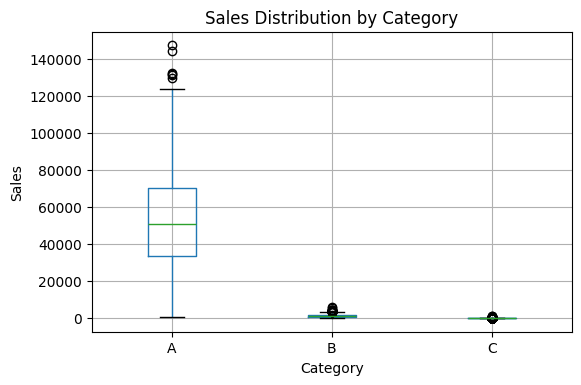

In [610]:
import matplotlib.pyplot as plt

tdf.boxplot(column='Sales', by='Category', figsize=(6, 4))

plt.title('Sales Distribution by Category')
plt.suptitle('')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

In [611]:
tdf.groupby('Category')['Sales'].agg(
    rows='count', mean='mean', median='median', std='std', max='max',
    zero_pct=lambda s: (s==0).mean()*100
).round(1)

/tmp/ipykernel_1782/375543985.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tdf.groupby('Category')['Sales'].agg(


,rows,mean,median,std,max,zero_pct
Category,,,,,,
A,775,53154.0,50838.0,25851.8,147534.0,0.0
B,775,1156.1,990.0,852.7,5843.0,6.2
C,1395,22.7,2.0,75.8,1016.0,48.2


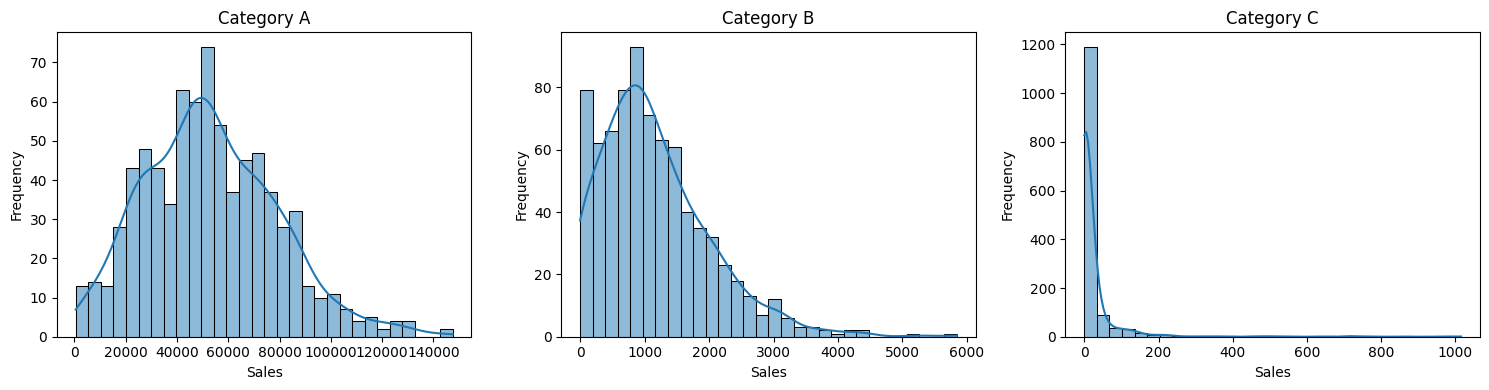

In [612]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, cat in zip(axes, ['A', 'B', 'C']):
    s = tdf.loc[tdf['Category'] == cat, 'Sales']

    sns.histplot(
        s,
        bins=30,
        kde=True,
        ax=ax
    )

    ax.set_title(f'Category {cat}')
    ax.set_xlabel('Sales')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

see the behavior over time for a particular store

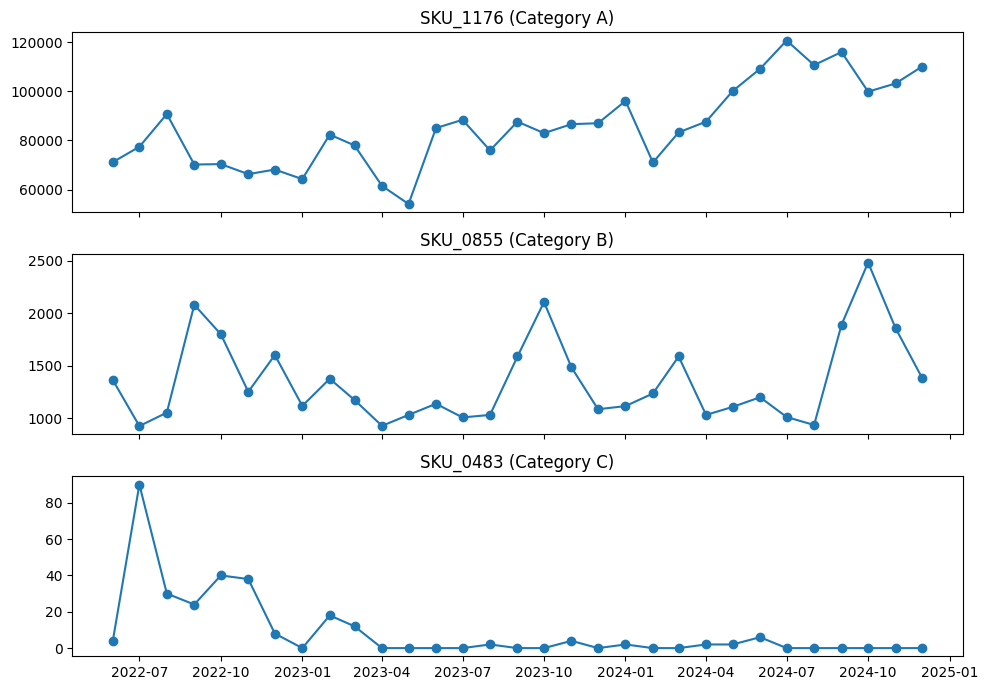

In [613]:
example = tdf[tdf.Store_ID == 'S01']
fig, axes = plt.subplots(3,1, figsize=(10,7), sharex=True)
for ax, cat in zip(axes, ['A','B','C']):
    sub = example[example.Category==cat]
    if len(sub)==0: continue
    sku = sub.SKU_ID.iloc[0]
    s = sub[sub.SKU_ID==sku].set_index('Month')['Sales']
    ax.plot(s.index, s.values, marker='o')
    ax.set_title(f'{sku} (Category {cat})')
plt.tight_layout(); plt.show()

3 random real examples per category, across different stores

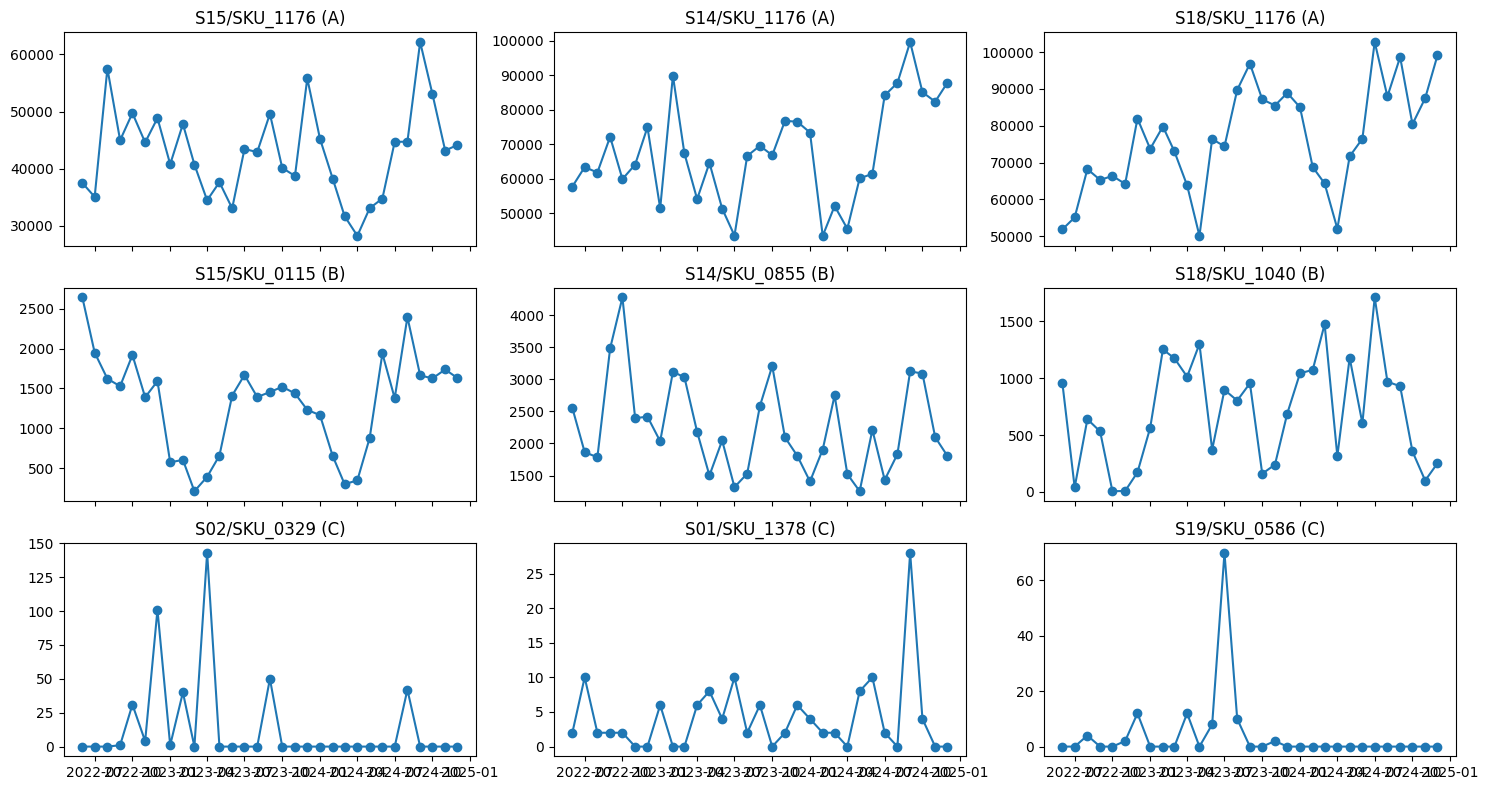

In [614]:
import random
cats = ['A','B','C']
fig, axes = plt.subplots(3, 3, figsize=(15,8), sharex=True)
for row, cat in enumerate(cats):
    sample_skus = tdf[tdf.Category==cat][['Store_ID','SKU_ID']].drop_duplicates().sample(3, random_state=1)
    for col, (_, r) in enumerate(sample_skus.iterrows()):
        s = tdf[(tdf.Store_ID==r.Store_ID) & (tdf.SKU_ID==r.SKU_ID)].set_index('Month')['Sales']
        axes[row, col].plot(s.index, s.values, marker='o')
        axes[row, col].set_title(f'{r.Store_ID}/{r.SKU_ID} ({cat})')
plt.tight_layout()
plt.show()

Monthly trend per category

/tmp/ipykernel_1782/324822189.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tdf.groupby(['Month','Category'])['Sales'].sum().unstack().plot(figsize=(12,5))


<Axes: xlabel='Month'>

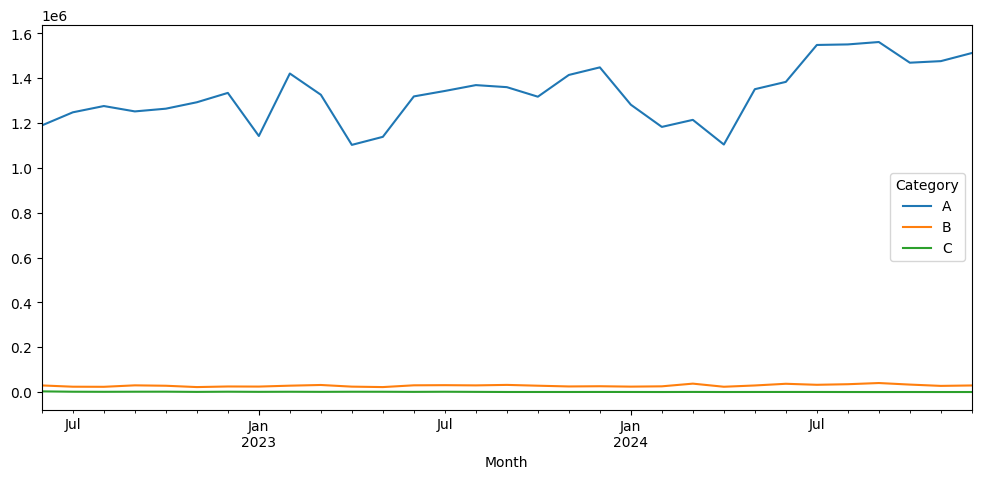

In [615]:
tdf.groupby(['Month','Category'])['Sales'].sum().unstack().plot(figsize=(12,5))

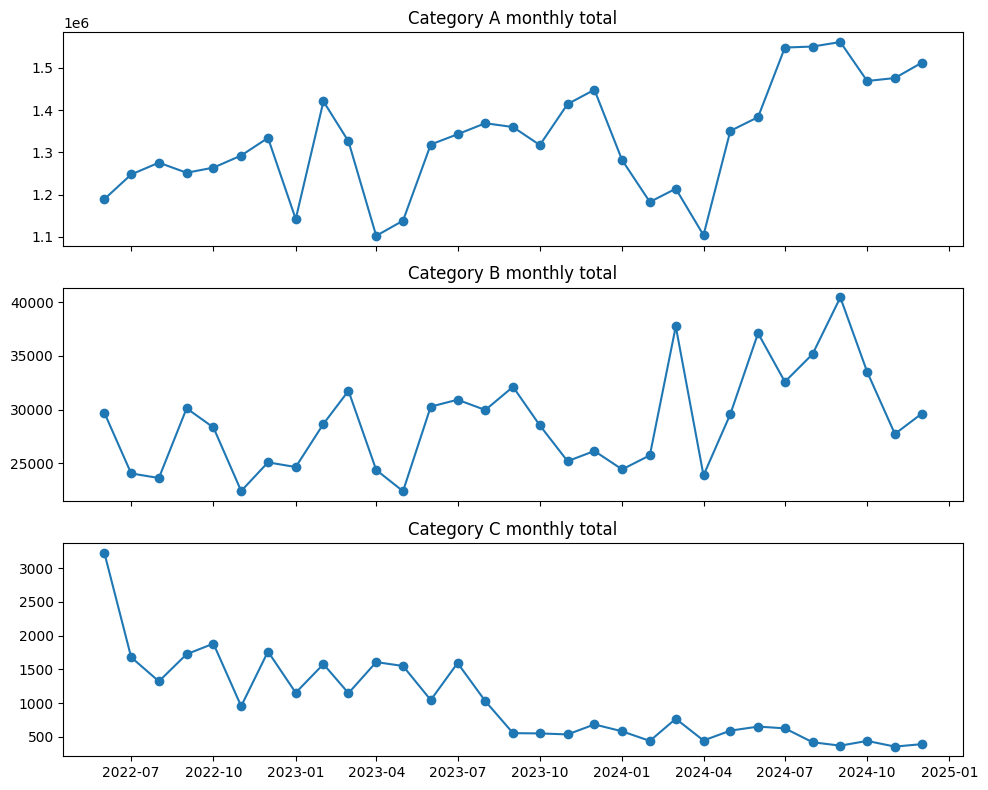

In [616]:
fig, axes = plt.subplots(3, 1, figsize=(10,8), sharex=True)
for ax, cat in zip(axes, ['A','B','C']):
    sub = tdf[tdf.Category==cat].groupby('Month')['Sales'].sum()
    ax.plot(sub.index, sub.values, marker='o')
    ax.set_title(f'Category {cat} monthly total')
plt.tight_layout()
plt.show()

In [617]:
tdfd = tdf.copy()
len(tdfd[['Store_ID','SKU_ID']].drop_duplicates())

95

outliers ?


In [618]:
tdf.shape

(2945, 7)

In [619]:
tdf["Sales"].describe()

,Sales
count,2945.000000
mean,14302.898812
std,26746.461595
min,0.000000
25%,2.000000
50%,262.000000
75%,14404.000000
max,147534.000000


In [620]:
Q1 = tdf['Sales'].quantile(0.25)
Q3 = tdf['Sales'].quantile(0.75)
IQR = Q3-Q1
LL = Q1-1.5*IQR
UL = Q3+1.5*IQR

In [621]:
t_outliers = ((tdf.Sales<LL )| (tdf.Sales>UL))

In [622]:
print(t_outliers.sum())
print((t_outliers.sum() / len(tdf)) * 100)

568
19.286926994906622


In [623]:
tdf[t_outliers].head(20)

,Store_ID,SKU_ID,Month,Sales,Category,BaselineForecast,Store_SKU
3,S01,SKU_1176,2022-06-01,71160.0,A,42525.27,S01_SKU_1176
9,S02,SKU_1176,2022-06-01,53630.0,A,45165.34,S02_SKU_1176
11,S03,SKU_1176,2022-06-01,57942.0,A,27153.23,S03_SKU_1176
13,S04,SKU_1176,2022-06-01,43779.0,A,20356.75,S04_SKU_1176
18,S05,SKU_1176,2022-06-01,36666.0,A,20387.79,S05_SKU_1176
42,S11,SKU_1176,2022-06-01,57172.0,A,0.00,S11_SKU_1176
45,S12,SKU_1176,2022-06-01,86303.0,A,33271.83,S12_SKU_1176
50,S13,SKU_1176,2022-06-01,60106.0,A,30582.79,S13_SKU_1176
53,S14,SKU_1176,2022-06-01,57683.0,A,32340.19,S14_SKU_1176
58,S15,SKU_1176,2022-06-01,37480.0,A,23301.53,S15_SKU_1176


In [624]:
tdf[t_outliers]["SKU_ID"].value_counts().head(10)

,count
SKU_ID,
SKU_1176,568


In [625]:
tdf[t_outliers]["Month"].value_counts()

,count
Month,
2024-07-01,20
2024-11-01,20
2024-10-01,20
2023-08-01,19
2022-10-01,19
2022-11-01,19
2023-02-01,19
2023-12-01,19
2023-11-01,19


In [626]:
tdf[t_outliers]["Category"].value_counts()

,count
Category,
A,568
B,0
C,0


In [627]:
tdf["SKU_ID"].nunique()

63

In [628]:
tdf[t_outliers]["Store_ID"].value_counts()

,count
Store_ID,
S01,31
S02,31
S03,31
S04,31
S11,31
S12,31
S25,31
S13,31
S14,31


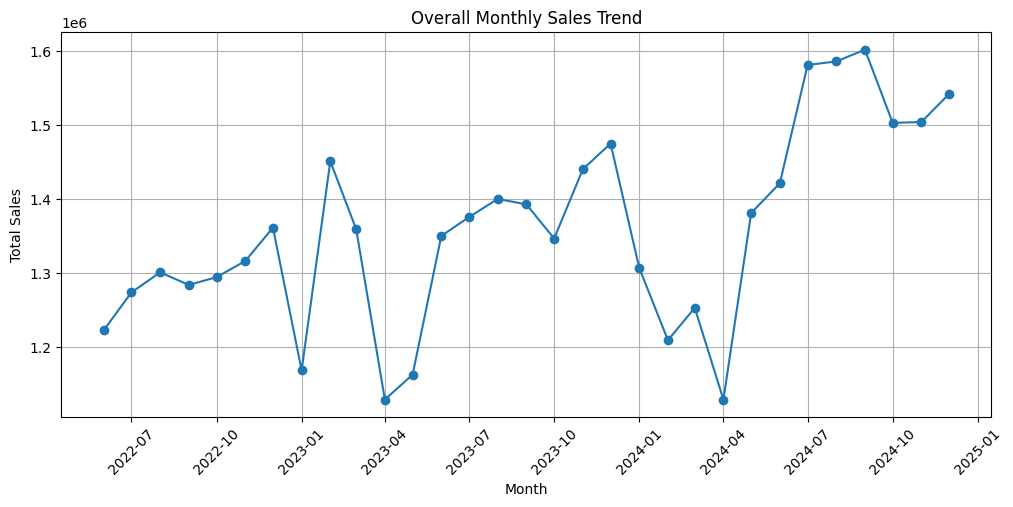

In [629]:
import matplotlib.pyplot as plt

monthly_sales = tdf.groupby("Month")["Sales"].sum()

plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title("Overall Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()